Successfully loaded 'emotions.jpg' with dimensions (626, 626, 3).
Detected 9 face(s).
[{'emotion': {'angry': np.float32(0.0798319), 'disgust': np.float32(4.83461e-12), 'fear': np.float32(0.00199788), 'happy': np.float32(0.000791916), 'sad': np.float32(1.421546), 'surprise': np.float32(0.003179046), 'neutral': np.float32(98.49265)}, 'dominant_emotion': 'neutral', 'region': {'x': 41, 'y': 38, 'w': 114, 'h': 114, 'left_eye': (118, 82), 'right_eye': (74, 84)}, 'face_confidence': 0.89}, {'emotion': {'angry': np.float32(41.264626), 'disgust': np.float32(1.9727734e-06), 'fear': np.float32(58.73525), 'happy': np.float32(5.24898e-05), 'sad': np.float32(6.2884224e-05), 'surprise': np.float32(2.3384182e-06), 'neutral': np.float32(1.4490166e-09)}, 'dominant_emotion': 'fear', 'region': {'x': 459, 'y': 45, 'w': 114, 'h': 114, 'left_eye': (538, 89), 'right_eye': (492, 91)}, 'face_confidence': 0.9}, {'emotion': {'angry': np.float32(8.364347e-08), 'disgust': np.float32(1.0053132e-27), 'fear': np.float3

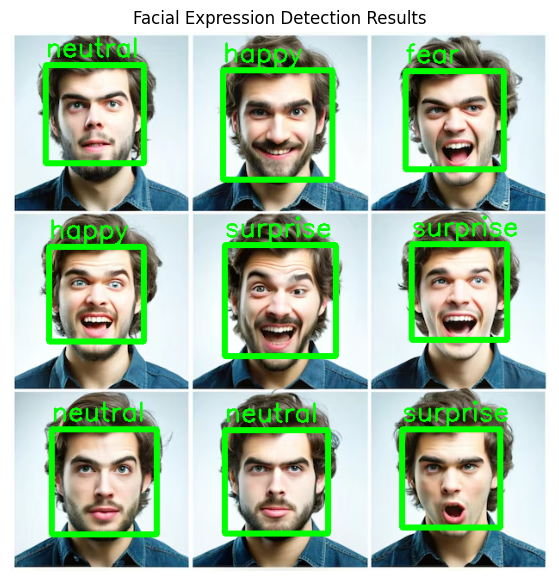

In [ ]:
# Install DeepFace
!pip install deepface --quiet

# Import libraries
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

# Path to your image
image_path = 'emotions.jpg'

# Load image using OpenCV
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    print(f"Error: The image at '{image_path}' could not be found.")
else:
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    print(f"Successfully loaded '{image_path}' with dimensions {img_rgb.shape}.")

    # Perform facial expression analysis
    results = DeepFace.analyze(
        img_path=img_rgb,
        actions=['emotion'],
        enforce_detection=False
    )

    # Ensure results is always a list for consistent iteration
    if isinstance(results, dict):
        results = [results]

    print(f"Detected {len(results)} face(s).")
    print(results)

    # Annotate image
    annotated_img = img_rgb.copy()
    for face in results:
        region = face['region']
        x, y, w, h = region['x'], region['y'], region['w'], region['h']
        emotion = face['dominant_emotion']

        # Draw bounding box (Green in RGB)
        cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (0, 255, 0), 5)
        cv2.putText(annotated_img, emotion, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Display annotated image
    plt.figure(figsize=(10, 7))
    plt.imshow(annotated_img)
    plt.title("Facial Expression Detection Results")
    plt.axis('off')
    plt.show()